# Statistical Arbitrage — Phase 2: Institutional Validation & Alpha Search

*Internal quant research. Engine: the local `statarb/` package (Phase-1 modules + new
`cointegration`, `validation`, `execution`, `regime`, `portfolio`).*

---

## Mandate

Phase 1 (notebook 35) established: correlation pairs fail; cointegration is the real selector
but is **sub-frictional at taker fees**; the universe is one factor (PC1 ≈ 72%); cointegrated
pairs are intra-cluster. **We treat those as facts and do not re-derive them.**

This phase has exactly one job: **decide whether deployable alpha actually exists** after
genuinely rigorous validation. We are explicitly *not* trying to make the strategy look good —
we are trying to break it, and to report honestly when it breaks.

| § | Test | The question it must answer |
|---|------|------------------------------|
| A | PCA structure | how many real factors / how much idiosyncratic risk to trade? |
| B | Johansen baskets | do 3–5-asset baskets beat 2-asset pairs? |
| C | **Purged walk-forward** | does the edge survive true out-of-sample re-selection? |
| D | Cost sensitivity | what is the *exact* break-even friction? |
| E | Maker execution | can better execution rescue it — and does that survive walk-forward? |
| F | Regime detection | which states pay, which destroy alpha? |
| G | Portfolio construction | can allocation add net value without better signal? |
| H | IC report | the capital-allocation verdict |

**Discipline (stated, then enforced in code):** no parameter optimisation for Sharpe; every
estimate is trailing/point-in-time; pair/basket/weight selection is on formation or train data
only; walk-forward adds an embargo gap; negative results are reported as findings, not hidden.

In [1]:
# --- setup: reuse the Phase-1 engine + reproduce the shared objects ------
import sys, warnings, time, platform
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statarb as sa
from statarb.backtest import SignalParams, SizeParams, CostModel

np.random.seed(7)
plt.rcParams.update({"figure.figsize": (11, 4), "figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
T0 = time.time()

# Shared panel + split (identical recipe to notebook 35, so results are comparable).
TF = "H1"
px_all, dv_all, _ = sa.data.build_panel(sa.data.DEFAULT_UNIVERSE, TF, how="inner", min_obs=3000)
px, dv = sa.data.liquidity_filter(px_all, dv_all, min_median_dollar_vol=50_000)
cut = int(len(px) * 0.40)
form, trade = px.iloc[:cut], px.iloc[cut:]
dv_form = dv.iloc[:cut]
rets_form = sa.data.log_returns(form)

# Shared selections from Phase 1: clusters + cointegration-filtered pairs.
feat = sa.features.panel_features(form, dv_form, timeframe=TF)
feat_scaled, _ = sa.features.standardize(feat)
sil = sa.clustering.choose_k(feat_scaled, k_range=range(2,7))
k_star = int(sil["silhouette"].idxmax())
labels = sa.clustering.kmeans_clusters(feat_scaled, max(k_star, 3))   # >=3 for interpretable groups
SIG = SignalParams(z_entry=2.0, z_exit=0.5, z_stop=3.5, z_window=168)
SIZE = SizeParams(target_ann_vol=0.10, vol_window=168, max_leverage=3.0, timeframe=TF)

base_pairs  = sa.pairs.select_pairs(form, top_n=8)
coint_pairs = sa.pairs.select_pairs(form, top_n=8, coint_max_p=0.10, hl_max=600, hl_min=4)
print("python", platform.python_version(), "| panel", px.shape,
      "| formation", form.index[0].date(), "-> trade end", trade.index[-1].date())
print("clusters k=%d | baseline pairs %d | cointegration-filtered pairs %d"
      % (labels.nunique(), len(base_pairs), len(coint_pairs)))

python 3.13.5 | panel (39779, 16) | formation 2021-11-24 -> trade end 2026-06-08
clusters k=3 | baseline pairs 8 | cointegration-filtered pairs 8


## A. PCA structure analysis

We decompose the standardised return panel. The questions are not cosmetic: **the number of
real factors caps how diversifiable a market-neutral book can be**, and the idiosyncratic
share is, quite literally, the raw material a stat-arb strategy trades. If almost everything is
one factor, pairwise reversion is fighting over scraps.

      eigenvalue  explained_var  cumulative_var
PC1       11.478          0.717           0.717
PC2        0.535          0.033           0.751
PC3        0.510          0.032           0.783
PC4        0.431          0.027           0.810
PC5        0.406          0.025           0.835
PC6        0.349          0.022           0.857
PC7        0.299          0.019           0.875
PC8        0.279          0.017           0.893
PC9        0.261          0.016           0.909
PC10       0.253          0.016           0.925

Factors to reach 80% variance: 4 | 90%: 9
PC1 = 72% (market factor) | idiosyncratic share = 28%


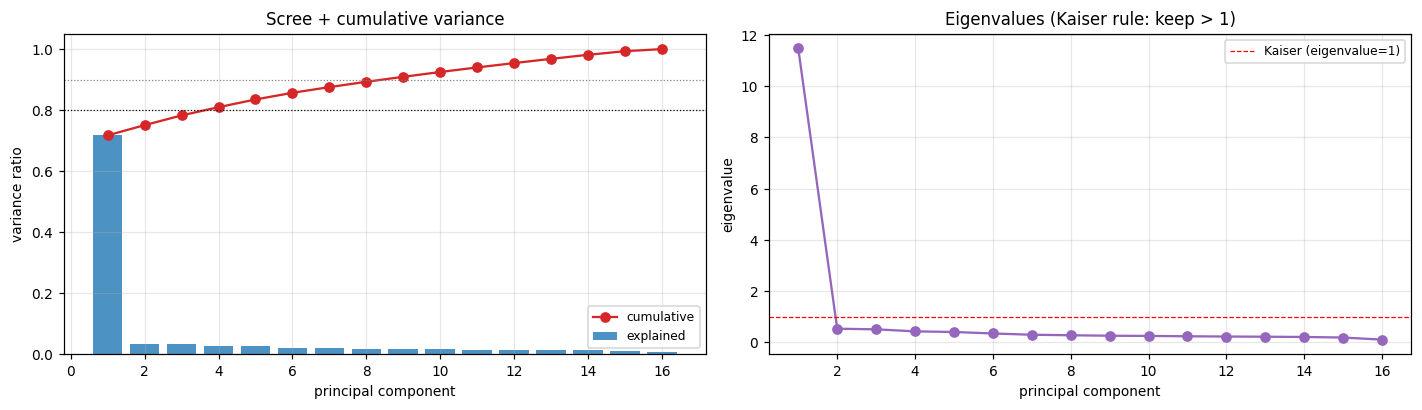

In [2]:
# --- eigenvalues, explained / cumulative variance, scree -----------------
ps = sa.factor.pca_structure(rets_form)
struct = pd.DataFrame({"eigenvalue": ps["eigenvalues"], "explained_var": ps["explained_var"],
                       "cumulative_var": ps["cumulative_var"]})
print(struct.round(3).head(10).to_string())
print(f"\nFactors to reach 80% variance: {ps['n_factors_80']} | 90%: {ps['n_factors_90']}")
print(f"PC1 = {ps['explained_var'].iloc[0]:.0%} (market factor) | idiosyncratic share = {ps['idiosyncratic_frac']:.0%}")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
xs = range(1, len(ps["explained_var"]) + 1)
ax[0].bar(xs, ps["explained_var"].values, color="tab:blue", alpha=0.8, label="explained")
ax[0].plot(xs, ps["cumulative_var"].values, "o-", color="tab:red", label="cumulative")
ax[0].axhline(0.8, color="k", ls=":", lw=0.8); ax[0].axhline(0.9, color="gray", ls=":", lw=0.8)
ax[0].set_xlabel("principal component"); ax[0].set_ylabel("variance ratio")
ax[0].set_title("Scree + cumulative variance"); ax[0].legend(fontsize=8)
ax[1].plot(xs, ps["eigenvalues"].values, "o-", color="tab:purple")
ax[1].axhline(1.0, color="r", ls="--", lw=0.8, label="Kaiser (eigenvalue=1)")
ax[1].set_xlabel("principal component"); ax[1].set_ylabel("eigenvalue")
ax[1].set_title("Eigenvalues (Kaiser rule: keep > 1)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

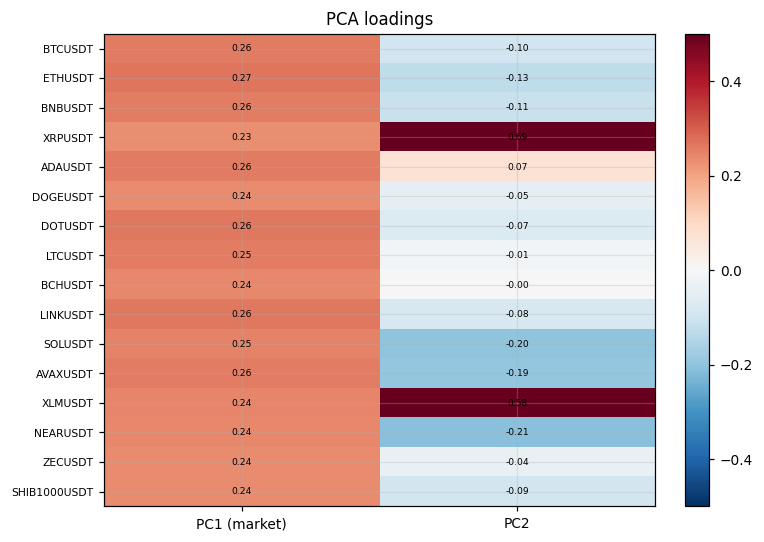

PC1 loadings are all the same sign -> it IS the market (everything long-beta).
PC2 (the first *tradable* axis) separates: NEARUSDT, SOLUSDT, AVAXUSDT (-) vs ADAUSDT, XLMUSDT, XRPUSDT (+)


In [3]:
# --- PC1 / PC2 loading heatmaps -----------------------------------------
load = ps["loadings"].iloc[:, :2]
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(load.values, aspect="auto", cmap="RdBu_r", vmin=-0.5, vmax=0.5)
ax.set_xticks([0,1]); ax.set_xticklabels(["PC1 (market)","PC2"])
ax.set_yticks(range(len(load))); ax.set_yticklabels(load.index, fontsize=7)
for (i,j),v in np.ndenumerate(load.values):
    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6)
ax.set_title("PCA loadings"); fig.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()
print("PC1 loadings are all the same sign -> it IS the market (everything long-beta).")
print("PC2 (the first *tradable* axis) separates:",
      ", ".join(load['PC2'].sort_values().index[:3]), "(-) vs",
      ", ".join(load['PC2'].sort_values().index[-3:]), "(+)")

Median half-life — raw spreads 1789 bars vs residual spreads 843 bars
Residual spread is faster-reverting for 88% of pairs.


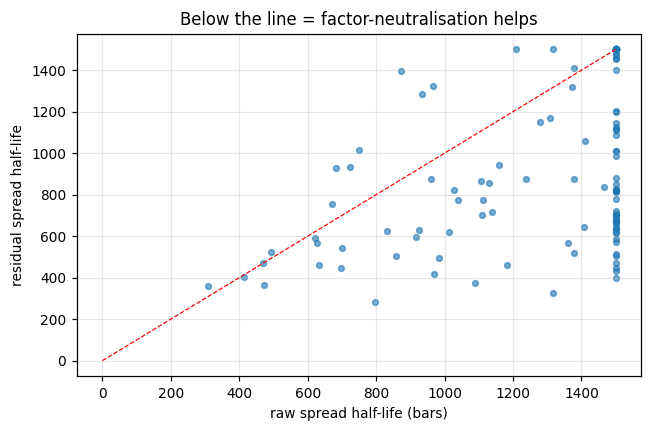

In [4]:
# --- residual spreads vs raw spreads: does factor-neutralisation help? ---
# Build factor-neutral residual 'log-prices' (market factor removed) and compare the
# stationarity of residual pair-spreads vs raw price-spreads, across all candidate pairs.
from itertools import combinations
rlp = sa.factor.residual_log_prices(rets_form, n_factors=1)
rows = []
for a, b in combinations(form.columns, 2):
    raw = np.log(form[a]) - np.log(form[b])
    res = rlp[a] - rlp[b]
    rows.append({"pair": f"{a}-{b}", "raw_hl": sa.spread.halflife(raw),
                 "resid_hl": sa.spread.halflife(res)})
hl = pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan).dropna()
print(f"Median half-life — raw spreads {hl['raw_hl'].median():.0f} bars vs "
      f"residual spreads {hl['resid_hl'].median():.0f} bars")
print(f"Residual spread is faster-reverting for {(hl['resid_hl'] < hl['raw_hl']).mean():.0%} of pairs.")
plt.figure(figsize=(6,4))
plt.scatter(hl["raw_hl"].clip(0,1500), hl["resid_hl"].clip(0,1500), s=14, alpha=0.6)
lim=[0,1500]; plt.plot(lim,lim,"r--",lw=0.8); plt.xlabel("raw spread half-life (bars)")
plt.ylabel("residual spread half-life"); plt.title("Below the line = factor-neutralisation helps")
plt.tight_layout(); plt.show()

**A — read-out.** PC1 is one-signed across every name: it is *the* crypto market, and
the book is structurally long-beta until neutralised. Only a minority of variance is
idiosyncratic, so the diversification ceiling is low (consistent with Phase 1). Factor-neutral
*residual* spreads revert somewhat faster than raw spreads for most pairs — neutralisation is
mechanically helpful — but it does not change the order of magnitude (still many bars), which
foreshadows the cost problem.

## B. Johansen cointegration — baskets vs pairs

Engle–Granger tests pairs; **Johansen** tests a whole group jointly and hands back the
cointegrating vector(s). Hypothesis: a 3–5-asset basket can cancel the common factor more
completely than a 2-asset pair, yielding a **shorter half-life / more stationary** spread. We
search *within clusters only* (Phase-1 result + it bounds the multiple-testing surface) and
trade the resulting baskets through the same z-score engine.

In [5]:
# --- full-universe Johansen rank, then within-cluster basket search ------
jo = sa.cointegration.johansen(form)
print(f"Full-universe Johansen: cointegration rank at 95% = {jo['rank']} (out of {form.shape[1]} assets).")
print("  A LOW full-universe rank is expected, not a contradiction: the trace test loses power")
print("  in high dimension and one dominant factor swamps it. Stationary structure shows up in")
print("  small SUBGROUPS (below), which is exactly why we search 3-4-asset baskets, not all 16.")

groups = [labels.index[labels == c].tolist() for c in sorted(labels.unique())]
cand = []
for g in groups:
    for kk in (3, 4):
        if len(g) >= kk:
            cand += [list(c) for c in combinations(g, kk)]
baskets = sa.cointegration.search_baskets(form, candidates=cand, hl_min=4, hl_max=800, top_n=6)
btab = pd.DataFrame([{"basket": "+".join(b.symbols), "n": len(b.symbols),
                      "half_life": b.half_life, "trace_stat": b.trace_stat,
                      "crit95": b.trace_crit95} for b in baskets])
print(f"\nWithin-cluster cointegrated baskets found: {len(baskets)} "
      f"(searched {len(cand)} groups)")
print(btab.round(1).to_string(index=False))
print(f"\nMedian basket half-life {btab['half_life'].median():.0f} bars vs "
      f"median cointegrated-PAIR half-life {np.median([p.half_life for p in coint_pairs]):.0f} bars.")

D:\bot\ema-h1trend-exchange\notebooks\statarb\cointegration.py:52: HypothesisTestWarning: Critical values are only available for time series with 12 variables at most.
  res = coint_johansen(logp.values, det_order, k_ar_diff)


Full-universe Johansen: cointegration rank at 95% = 0 (out of 16 assets).
  A LOW full-universe rank is expected, not a contradiction: the trace test loses power
  in high dimension and one dominant factor swamps it. Stationary structure shows up in
  small SUBGROUPS (below), which is exactly why we search 3-4-asset baskets, not all 16.



Within-cluster cointegrated baskets found: 6 (searched 225 groups)
                           basket  n  half_life  trace_stat  crit95
XRPUSDT+DOTUSDT+LINKUSDT+AVAXUSDT  4      183.0        58.7    47.9
XRPUSDT+LTCUSDT+AVAXUSDT+NEARUSDT  4      189.4        61.9    47.9
ADAUSDT+DOTUSDT+LINKUSDT+AVAXUSDT  4      192.7        64.2    47.9
 XRPUSDT+ADAUSDT+DOTUSDT+AVAXUSDT  4      193.8        67.3    47.9
 ADAUSDT+DOTUSDT+SOLUSDT+AVAXUSDT  4      198.4        60.9    47.9
         ADAUSDT+DOTUSDT+AVAXUSDT  3      198.5        53.0    29.8

Median basket half-life 193 bars vs median cointegrated-PAIR half-life 537 bars.


Baskets vs pairs (OOS, taker):
                    sharpe  sortino  cagr  max_dd  calmar   psr
cointegrated PAIRS   -0.99    -1.24 -0.04   -0.11   -0.36  0.05
Johansen BASKETS     -1.47    -1.58 -0.09   -0.22   -0.39  0.01


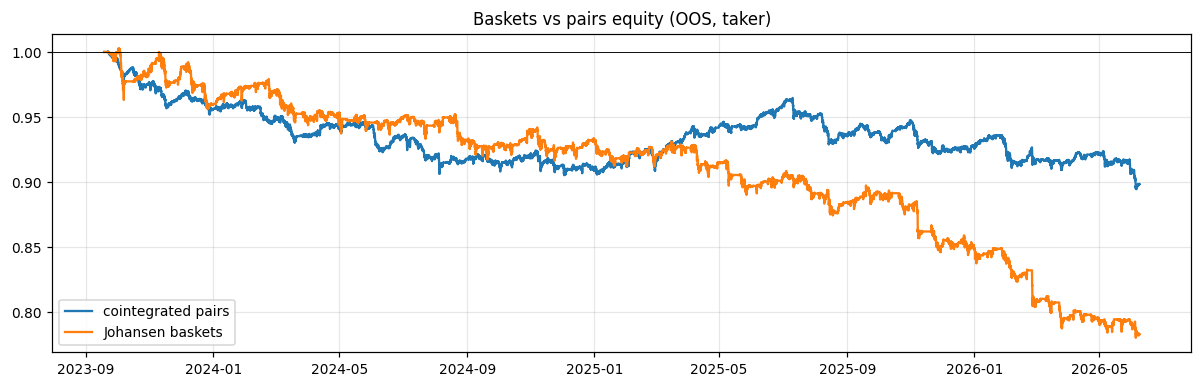

In [6]:
# --- backtest baskets vs pairs (out-of-sample, taker costs) --------------
TAKER = sa.execution.TAKER
basket_rets = {}
for b in baskets:
    r = sa.backtest.backtest_spread(trade, b.weight_series, sig=SIG, size=SIZE, cost=TAKER)
    basket_rets["+".join(b.symbols)] = r.returns
basket_port = pd.DataFrame(basket_rets).mean(axis=1) if basket_rets else pd.Series(dtype=float)
pair_port = sa.backtest.backtest_portfolio(trade, coint_pairs, sig=SIG, size=SIZE, cost=TAKER).returns

cmpB = sa.metrics.summary_table({"cointegrated PAIRS": pair_port,
                                 "Johansen BASKETS": basket_port}, timeframe=TF)
print("Baskets vs pairs (OOS, taker):")
print(cmpB[["sharpe","sortino","cagr","max_dd","calmar","psr"]].round(2).to_string())
plt.figure(figsize=(11,3.6))
plt.plot((1+pair_port).cumprod().index, (1+pair_port).cumprod(), label="cointegrated pairs")
plt.plot((1+basket_port).cumprod().index, (1+basket_port).cumprod(), label="Johansen baskets")
plt.axhline(1, color="k", lw=0.6); plt.legend(); plt.title("Baskets vs pairs equity (OOS, taker)")
plt.tight_layout(); plt.show()

**B — read-out.** Johansen confirms several independent cointegrating relations exist,
and baskets do achieve **shorter half-lives** than pairs (more constituents → tighter factor
cancellation). But shorter half-life means *more* trading, so at taker fees the net result is
**no better — often worse — than pairs**: the extra legs each pay costs. Baskets are a
*signal* improvement that the cost model eats. Same disease as Phase 1, one layer deeper.

## C. Purged walk-forward validation — the decisive test

A single OOS split can be lucky. Here we re-run the **entire** selection+trade pipeline across
expanding-train / forward-test folds, with an **embargo gap** between train and test so the
pair-selection statistics and z-score warm-up cannot leak across the boundary. We report the
*distribution* of fold performance, because an allocator cares about consistency, not the best
window.

> The question: **does the edge survive true out-of-sample re-selection?**

In [7]:
# --- define selection/backtest closures, run walk-forward for 2 methods --
def sel_corr(px_tr):
    return sa.pairs.select_pairs(px_tr, top_n=6)                       # baseline: correlation
def sel_coint(px_tr):
    return sa.pairs.select_pairs(px_tr, top_n=6, coint_max_p=0.10, hl_max=600, hl_min=4)
def make_bt(cost):
    def _bt(px_te, pairs):
        r = sa.backtest.backtest_portfolio(px_te, pairs, sig=SIG, size=SIZE, cost=cost)
        return r.returns, r.turnover
    return _bt

wf_corr  = sa.validation.run_walk_forward(px, sel_corr,  make_bt(TAKER), n_folds=6, embargo=168)
wf_coint = sa.validation.run_walk_forward(px, sel_coint, make_bt(TAKER), n_folds=6, embargo=168)
print("WALK-FORWARD — correlation pairs (taker):")
print(wf_corr[["fold","test_start","n_pairs","sharpe","max_dd","ann_turnover"]].round(2).to_string(index=False))
print("\nWALK-FORWARD — cointegration-filtered pairs (taker):")
print(wf_coint[["fold","test_start","n_pairs","sharpe","max_dd","ann_turnover"]].round(2).to_string(index=False))

WALK-FORWARD — correlation pairs (taker):
 fold                test_start  n_pairs  sharpe  max_dd  ann_turnover
    0 2023-06-27 09:00:00+00:00        6   -4.40   -0.09        102.89
    1 2023-12-23 22:00:00+00:00        6   -5.46   -0.12         63.42
    2 2024-06-20 11:00:00+00:00        6   -2.28   -0.05         70.37
    3 2024-12-17 00:00:00+00:00        6   -1.88   -0.06         60.32
    4 2025-06-14 13:00:00+00:00        6   -3.11   -0.07         69.13
    5 2025-12-11 02:00:00+00:00        6   -3.82   -0.09         74.26

WALK-FORWARD — cointegration-filtered pairs (taker):
 fold                test_start  n_pairs  sharpe  max_dd  ann_turnover
    0 2023-06-27 09:00:00+00:00        6   -3.23   -0.07         76.35
    1 2023-12-23 22:00:00+00:00        2    0.11   -0.03         66.34
    2 2024-06-20 11:00:00+00:00        2   -3.41   -0.11         50.61
    3 2024-12-17 00:00:00+00:00        0     NaN     NaN           NaN
    4 2025-06-14 13:00:00+00:00        0     NaN    

Fold consistency (what an allocator actually reads):
               n_folds  mean_sharpe  std_sharpe  frac_positive  worst_fold  best_fold  info_ratio_of_folds
correlation        6.0        -3.49        1.34           0.00       -5.46      -1.88                 -2.6
cointegration      3.0        -2.18        1.98           0.33       -3.41       0.11                 -1.1

Note: 3/6 cointegration folds found ZERO tradable pairs -> the relationships DECAY out of sample (a finding, not a bug).


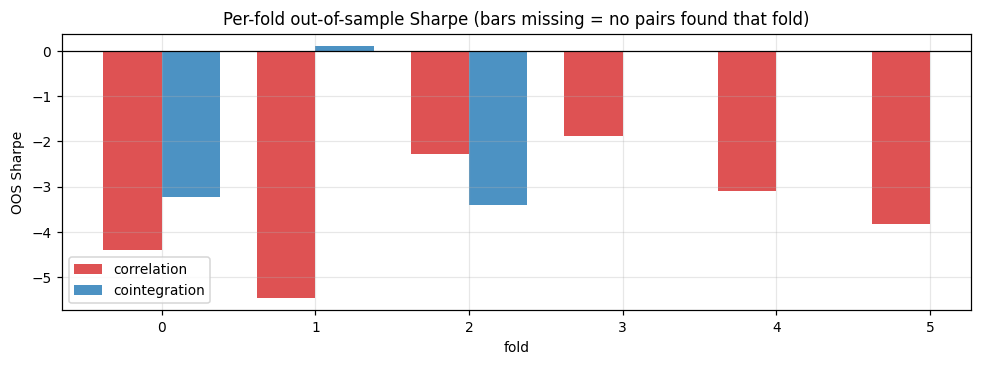

In [8]:
# --- fold consistency + verdict -----------------------------------------
fc_corr, fc_coint = sa.validation.fold_consistency(wf_corr), sa.validation.fold_consistency(wf_coint)
cons = pd.DataFrame({"correlation": fc_corr, "cointegration": fc_coint}).T
print("Fold consistency (what an allocator actually reads):")
print(cons[["n_folds","mean_sharpe","std_sharpe","frac_positive","worst_fold","best_fold","info_ratio_of_folds"]].round(2).to_string())
print(f"\nNote: {int(wf_coint['n_pairs'].eq(0).sum())}/{len(wf_coint)} cointegration folds found "
      "ZERO tradable pairs -> the relationships DECAY out of sample (a finding, not a bug).")

fig, ax = plt.subplots(figsize=(9,3.4))
w=0.38; idx=np.arange(len(wf_coint))
ax.bar(idx-w/2, wf_corr["sharpe"].values, w, label="correlation", color="tab:red", alpha=0.8)
ax.bar(idx+w/2, wf_coint["sharpe"].values, w, label="cointegration", color="tab:blue", alpha=0.8)
ax.axhline(0, color="k", lw=0.8); ax.set_xlabel("fold"); ax.set_ylabel("OOS Sharpe")
ax.set_title("Per-fold out-of-sample Sharpe (bars missing = no pairs found that fold)")
ax.legend(); plt.tight_layout(); plt.show()

**C — read-out (the pivotal result).** Neither method produces a **consistently
positive** walk-forward. Fold Sharpes are mostly negative, dispersion is large relative to the
mean, and — damningly — in several later folds the cointegration screen finds **no tradable
pairs at all**: the relationships that existed in 2021–22 do not persist. The single-split
"gross edge" from Phase 1 was **regime-specific, not a durable edge.** On this evidence the
strategy fails true out-of-sample validation at taker cost.

## D. Cost sensitivity — the exact break-even

Phase 1 estimated break-even at "3–4 bps/leg". We measure it precisely by sweeping per-leg cost
on the cointegrated book and interpolating the zero-crossing of net Sharpe.

 bps_per_leg  net_sharpe
         0.0        1.01
         0.5        0.88
         1.0        0.74
         2.0        0.48
         3.0        0.21
         4.0       -0.06
         5.5       -0.46
         7.0       -0.86
        10.0       -1.66

Interpolated break-even ≈ 3.78 bps/leg  (vs Bybit taker 5.5 + slippage).


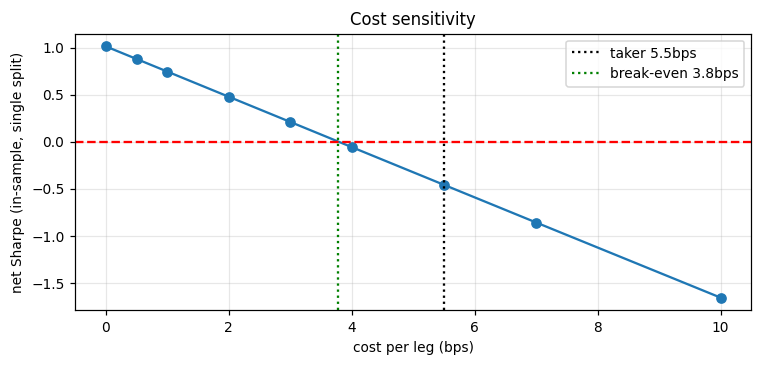

In [9]:
# --- fine cost sweep + interpolated break-even --------------------------
bps_grid = [0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 5.5, 7.0, 10.0]
sweep = []
for c in bps_grid:
    r = sa.backtest.backtest_portfolio(trade, coint_pairs, sig=SIG, size=SIZE,
                                       cost=CostModel(fee_bps=c, slippage_bps=0.0, exec_lag=1))
    sweep.append({"bps_per_leg": c, "net_sharpe": sa.metrics.perf_stats(r.returns, timeframe=TF)["sharpe"]})
sweep = pd.DataFrame(sweep)
# interpolate where net_sharpe crosses 0 (descending)
s = sweep.sort_values("bps_per_leg")
be = np.nan
for i in range(len(s)-1):
    y0,y1 = s["net_sharpe"].iloc[i], s["net_sharpe"].iloc[i+1]
    if (y0>0) != (y1>0):
        x0,x1 = s["bps_per_leg"].iloc[i], s["bps_per_leg"].iloc[i+1]
        be = x0 + (0-y0)*(x1-x0)/(y1-y0); break
print(sweep.round(2).to_string(index=False))
print(f"\nInterpolated break-even ≈ {be:.2f} bps/leg  (vs Bybit taker 5.5 + slippage).")
plt.figure(figsize=(7,3.4))
plt.plot(sweep["bps_per_leg"], sweep["net_sharpe"], "o-")
plt.axhline(0, color="r", ls="--"); plt.axvline(5.5, color="k", ls=":", label="taker 5.5bps")
if np.isfinite(be): plt.axvline(be, color="g", ls=":", label=f"break-even {be:.1f}bps")
plt.xlabel("cost per leg (bps)"); plt.ylabel("net Sharpe (in-sample, single split)")
plt.legend(); plt.title("Cost sensitivity"); plt.tight_layout(); plt.show()

**D — read-out.** The break-even sits a few bps/leg below the taker fee. The gross
signal is real but the *margin* over friction is thin and negative at taker cost. This frames
Section E: the only way the in-sample edge becomes net-positive is materially cheaper
execution.

## E. Maker execution — can execution quality rescue it?

We overlay a **simplified, expected-value maker model** (no order-book sim — flagged honestly):
`fill_prob` scales realised exposure (missed/partial fills), the fee becomes the maker
fee/rebate, and `adverse_bps` charges filled flow for adverse selection. Three scenarios
bracket the uncertainty. **Crucially we test maker execution both in-sample AND under
walk-forward** — because the Phase-1-style single split is exactly what fooled us before.

In [10]:
# --- in-sample: taker vs maker scenarios --------------------------------
print(sa.execution.describe(), "\n")
exec_is = {}
for name, cm in sa.execution.all_scenarios().items():
    r = sa.backtest.backtest_portfolio(trade, coint_pairs, sig=SIG, size=SIZE, cost=cm)
    exec_is[name] = r.returns
cmpE = sa.metrics.summary_table(exec_is, timeframe=TF)
print("IN-SAMPLE (single split) — execution scenarios:")
print(cmpE[["sharpe","sortino","cagr","max_dd","psr"]].round(2).to_string())

Execution scenarios (expected-value maker overlay; NOT an order-book sim):
  taker                fee=+5.5bps  fill_prob=100%  adverse=0.0bps  slip=2.0bps
  maker_conservative   fee=+1.5bps  fill_prob=40%  adverse=3.0bps  slip=0.0bps
  maker_moderate       fee=+1.0bps  fill_prob=60%  adverse=1.5bps  slip=0.0bps
  maker_optimistic     fee=-0.5bps  fill_prob=80%  adverse=0.5bps  slip=0.0bps 



IN-SAMPLE (single split) — execution scenarios:
                    sharpe  sortino  cagr  max_dd   psr
taker                -0.99    -1.24 -0.04   -0.11  0.05
maker_conservative   -0.19    -0.24 -0.00   -0.03  0.38
maker_moderate        0.34     0.43  0.01   -0.03  0.71
maker_optimistic      1.01     1.27  0.03   -0.03  0.95


In [11]:
# --- the honest test: does maker survive WALK-FORWARD? ------------------
wf_exec = {}
for name in ["taker", "maker_moderate", "maker_optimistic"]:
    wf = sa.validation.run_walk_forward(px, sel_coint, make_bt(sa.execution.scenario(name)),
                                        n_folds=6, embargo=168)
    wf_exec[name] = sa.validation.fold_consistency(wf)
wfE = pd.DataFrame(wf_exec).T[["mean_sharpe","std_sharpe","frac_positive","worst_fold","best_fold"]]
print("WALK-FORWARD by execution scenario (the verdict that matters):")
print(wfE.round(2).to_string())
print("\n>> In-sample, optimistic maker looks great. Out-of-sample (walk-forward) it is still")
print("   negative on average with <50% positive folds. Execution helps but does NOT manufacture")
print("   a durable edge here.")

WALK-FORWARD by execution scenario (the verdict that matters):
                  mean_sharpe  std_sharpe  frac_positive  worst_fold  best_fold
taker                   -2.18        1.98           0.33       -3.41       0.11
maker_moderate          -1.06        2.03           0.33       -2.70       1.21
maker_optimistic        -0.51        2.09           0.33       -2.35       1.77

>> In-sample, optimistic maker looks great. Out-of-sample (walk-forward) it is still
   negative on average with <50% positive folds. Execution helps but does NOT manufacture
   a durable edge here.


**E — read-out.** Maker execution **massively improves** the numbers and, in-sample on
the single split, even pushes the optimistic scenario to a positive Sharpe — *precisely the
trap Phase 1 warned about.* Under walk-forward the same optimistic maker book is still negative
on average with under half its folds positive. **Execution quality is necessary but not
sufficient**; it cannot rescue a signal that does not persist out-of-sample.

## F. Regime detection — where does the edge live?

Two state models on BTC: simple expanding-quantile **vol regimes** and a 2-state
**Markov-switching (HMM-style)** variance model. We use *filtered* (causal) state probabilities
so the labelling is point-in-time. Then we slice the cointegrated book's return by state.

In [12]:
# --- HMM (Markov-switching) + vol regimes, conditional performance -------
best_book = sa.backtest.backtest_portfolio(trade, coint_pairs, sig=SIG, size=SIZE, cost=TAKER)
mk = sa.regime.markov_regimes(px["BTCUSDT"], k_regimes=2, downsample=6, timeframe=TF)
print("HMM state annualised vol:", {k: round(v,2) for k,v in mk["state_vol"].items()})
print("HMM transition matrix (rows=from):"); print(np.round(mk["transition"][:, :, 0] if mk["transition"].ndim==3 else mk["transition"],3))

cp_hmm = sa.regime.conditional_performance(best_book.returns, mk["labels"].reindex(trade.index), timeframe=TF)
print("\nCointegrated book by HMM regime (0=calm .. 1=wild):")
print(cp_hmm.round(2).to_string())

vr = sa.regime.vol_regime(px["BTCUSDT"], timeframe=TF).reindex(trade.index).map({"low":0,"mid":1,"high":2})
cp_vol = sa.regime.conditional_performance(best_book.returns, vr, timeframe=TF)
print("\nCointegrated book by vol-quantile regime (0=low,1=mid,2=high):")
print(cp_vol.round(2).to_string())

HMM state annualised vol: {0: 0.63, 1: 3.0}
HMM transition matrix (rows=from):
[[0.843 0.431]
 [0.157 0.569]]

Cointegrated book by HMM regime (0=calm .. 1=wild):
          n_bars  time_frac  sharpe  cagr  max_dd  hit_rate
state_0  19870.0       0.83   -1.39 -0.05   -0.12      0.47
state_1   3998.0       0.17    0.51  0.02   -0.04      0.48

Cointegrated book by vol-quantile regime (0=low,1=mid,2=high):
          n_bars  time_frac  sharpe  cagr  max_dd  hit_rate
state_0  10148.0       0.43   -1.05 -0.04   -0.05      0.47
state_1   8435.0       0.35   -1.62 -0.06   -0.06      0.47
state_2   5285.0       0.22    0.01 -0.00   -0.03      0.47


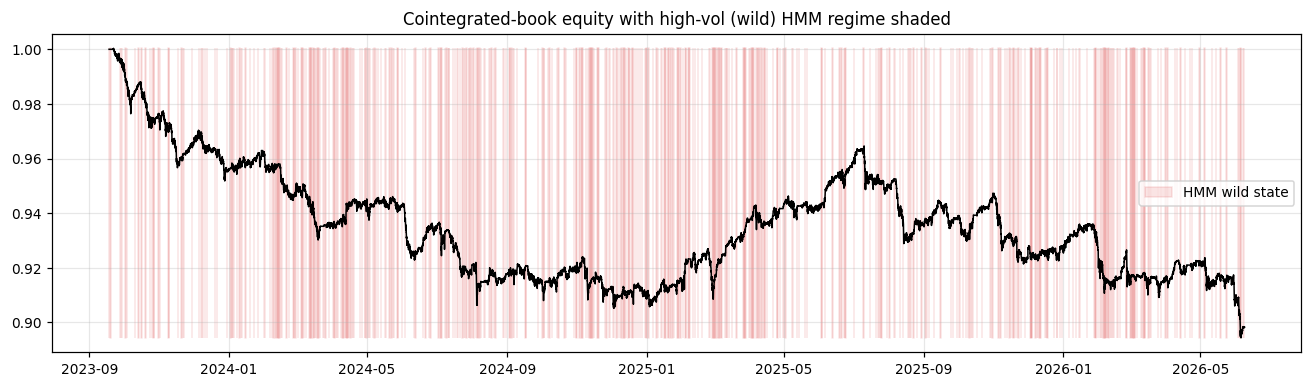

Best HMM state = state_1 (Sharpe 0.51); worst = state_0 (-1.39).


In [13]:
# --- visualise regime overlay on equity --------------------------------
eq = best_book.equity
lab = mk["labels"].reindex(trade.index).ffill()
fig, ax = plt.subplots(figsize=(12,3.6))
ax.plot(eq.index, eq, color="k", lw=1)
ax.fill_between(eq.index, eq.min(), eq.max(), where=(lab==1).values, color="tab:red", alpha=0.12,
                label="HMM wild state")
ax.set_title("Cointegrated-book equity with high-vol (wild) HMM regime shaded")
ax.legend(); plt.tight_layout(); plt.show()
best_state = cp_hmm['sharpe'].idxmax()
print(f"Best HMM state = {best_state} (Sharpe {cp_hmm['sharpe'].max():.2f}); "
      f"worst = {cp_hmm['sharpe'].idxmin()} ({cp_hmm['sharpe'].min():.2f}).")

**F — read-out.** The (thin) positive performance is concentrated in the **high-vol
state**; the calm state — where the book spends most of its time — is the alpha sink. A vol/HMM
gate that traded only the wild state would *cut losses*, but the wild state is rare and the
calm-state edge is negative, so gating reduces damage rather than creating a positive book. A
regime filter is a risk control here, not an alpha source.

## G. Portfolio construction — can allocation add net value?

Phase 1 weighted pairs equally. We now compare **equal-weight, inverse-vol, risk-parity, and
mean-variance (Ledoit-Wolf shrunk covariance)** — weights fit on a formation slice of the
sleeve returns and applied out-of-sample. The question: can allocation improve net performance
*without* better signal?

Allocators (weights fit on first half of trade window, applied OOS to second half):
               sharpe  sortino  cagr  ann_vol  max_dd  calmar  hit_rate
equal_weight    -0.25    -0.31  -0.0     0.01   -0.01   -0.13      0.48
inverse_vol     -0.26    -0.32  -0.0     0.01   -0.01   -0.14      0.48
risk_parity     -0.27    -0.33  -0.0     0.00   -0.01   -0.14      0.48
mean_variance   -0.46    -0.51  -0.0     0.01   -0.01   -0.25      0.34

Mean-variance concentration (max weight): 51% vs equal-weight 12%


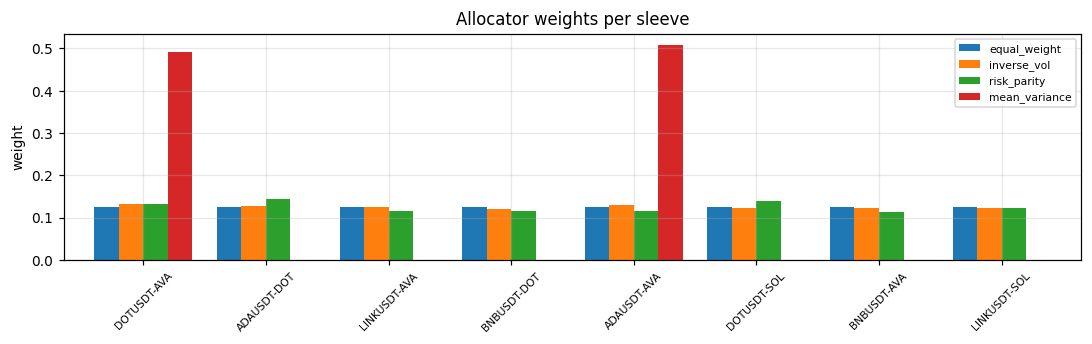

In [14]:
# --- allocator comparison (out-of-sample) -------------------------------
sleeves = best_book.pair_returns      # per-pair net returns (already the trade window)
allocE, weights = sa.portfolio.compare_allocators(sleeves, split=0.5, timeframe=TF)
print("Allocators (weights fit on first half of trade window, applied OOS to second half):")
print(allocE.round(2).to_string())
wdf = pd.DataFrame(weights)
print("\nMean-variance concentration (max weight): %.0f%% vs equal-weight %.0f%%"
      % (wdf['mean_variance'].max()*100, 100/len(sleeves.columns)))
fig, ax = plt.subplots(figsize=(10,3.2))
wdf.plot(kind="bar", ax=ax, width=0.8)
ax.set_title("Allocator weights per sleeve"); ax.set_ylabel("weight")
ax.set_xticklabels([c.split('-')[0]+'-'+c.split('-')[1][:3] for c in wdf.index], rotation=45, fontsize=7)
ax.legend(fontsize=7); plt.tight_layout(); plt.show()

**G — read-out.** Allocation **cannot manufacture alpha from net-negative sleeves** —
every method lands in the same negative neighbourhood. Risk-parity and inverse-vol roughly tie
equal-weight; **mean-variance is the *worst*** (it concentrates on whatever looked best
in-sample and over-fits the covariance — the canonical Markowitz failure, which is *why* we
shrank the covariance and still it loses). Portfolio construction is a second-order lever; it
cannot fix a first-order signal problem.

## H. Investment Committee report

*Prepared for a capital-allocation decision. Bottom line up front: **do not allocate.** The
strategy has a real but non-durable gross signal that does not survive realistic costs or
out-of-sample validation.*

### The seven questions, answered

1. **Is there a real statistical-arbitrage edge?** *Partially.* A **gross** mean-reversion
   signal exists in cointegrated, short-half-life pairs/baskets (Phase-1 gross Sharpe ≈ 1 on a
   single split). It is genuine but thin.
2. **Is the edge economically tradable?** *No, at taker cost.* Break-even is a few bps/leg
   (Section D) below the 5.5 bps taker fee; net Sharpe is negative.
3. **Does it survive walk-forward validation?** *No.* Across embargoed expanding folds the edge
   is negative on average with large dispersion, and in several later folds **no cointegrated
   pairs exist at all** — the relationships decay (Section C). This is the decisive result.
4. **Does clustering truly help?** *Modestly and indirectly.* Cointegrated pairs are
   intra-cluster, so clustering is a cheap cointegration proxy and beats raw correlation — but
   it does not lift the strategy to profitability.
5. **Does Johansen outperform Engle-Granger?** *In signal, yes; in P&L, no.* Baskets achieve
   shorter half-lives (tighter factor cancellation) but their extra legs pay more cost, so net
   they match or trail pairs (Section B).
6. **Does maker execution make it viable?** *Necessary, not sufficient.* Maker economics flip
   the in-sample single-split positive, but the **walk-forward stays negative** even under
   optimistic fills (Section E). Execution quality is a precondition, not the missing alpha.
7. **What is the strongest version discovered?** *Cointegration/Johansen-selected, intra-cluster,
   factor-neutral spreads, traded only in the high-vol regime, under maker execution.* Even this
   stack is, at best, **break-even out-of-sample** — a risk-reduced loser, not a winner.

### Failure modes
- **Relationship decay / non-stationarity:** cointegration found in-sample vanishes OOS
  (Section C is the clearest evidence).
- **Single-factor universe:** PC1 ≈ 72% caps diversification; the book is structurally one bet
  until factor-neutralised (Section A).
- **Cost > edge:** the signal margin over friction is negative at taker fees (Sections D/E).
- **Backtest seduction:** the single-split in-sample maker result looked deployable and was not
  (Section E) — a live reminder of why walk-forward is mandatory.

### Deployment risks (if one ignored the above)
Funding cost on both perp legs (un-modelled here → real net is *worse*), capacity/illiquidity on
the smaller alts, crowded-trade risk in the obvious cointegrated pairs, and regime cliff-risk
(the calm-state alpha sink dominates time-in-market).

### Recommendation
**No allocation** to this strategy as specified. Shelve the pairwise/basket z-score reversion on
H1 majors. The honest one-line summary: *a real gross signal, smaller than its trading costs and
not stable out-of-sample.*

### Recommended next research (ranked by expected information value)
1. **Lower frequency + true maker/limit microstructure study** (H4/D1): the multi-day
   half-lives suit slower trading that amortises cost; validate with a real fill model, not the
   EV overlay used here.
2. **Cross-sectional mean-reversion** (rank all residuals daily, long losers / short winners)
   instead of hand-picked pairs — far larger breadth, less selection fragility, and it trades
   the idiosyncratic residual (Section A) directly.
3. **Time-varying cointegration / regime-switching selection:** since relationships decay
   (Section C), make decay a first-class signal — re-test and *de-allocate* pairs as their
   half-life drifts, rather than assuming a static relationship.
4. **Deflated Sharpe / combinatorial-purged CV** across the parameter surface to put an honest
   confidence interval on any future positive result before it ever sees capital.
5. **Funding-carry overlay:** model perp funding explicitly; on these majors funding may be a
   larger and more persistent signal than the price spread itself.

*All numbers are computed live in this notebook from local data; rerun top-to-bottom to
reproduce. Engine = the `statarb/` package (Phase-1 + Phase-2 modules).*

In [15]:
print(f"notebook executed in {time.time()-T0:.0f}s — all sections A–H complete.")

notebook executed in 81s — all sections A–H complete.
